# 2) Analyze source collection and target file

This notebook includes the code to analyze the collection of sounds compiled in the previous notebook and that will be later used as the source collection in our audio mosaicing code. The notebook also contains the code to analyze the target audio file that will be later reconstructed using sound chunks from the source collection.

The audio analysis carried out in this notebook uses the Pythonn bindings of the Essentia library which was introduced in the first session of AMPLAB. Please make sure you checked the [Essentia Python tutorial](https://essentia.upf.edu/documentation/essentia_python_tutorial.html) to get familiarized with using Essentia in Python. Also useful is to always have a browser tab opened with Essentia's [Algorithms Reference](https://essentia.upf.edu/documentation/algorithms_reference.html) documentation page.

In [ ]:
# Essentia
!pip install essentia
# Freesound-python
!pip install git+https://github.com/mtg/freesound-python.git
# Mount drive and cd to notebook folder
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Replace with your path
%cd '/content/drive/MyDrive/SMC/ACTSM2026/Block II/Session 1 - Sound retrieval with Freesound and Creative Applications'

In [5]:
import pandas as pd
import essentia
import essentia.standard as estd
import matplotlib.pyplot as plt
from IPython.display import display, Audio

In [6]:
# Define here our sound analysis function
# NOTE: remember that if you update this function and want to run a new analysis you'll need to re-run both
# this cell and the cells below that carry out the audio analysis and that call the analysis function.
# After analyzing the source collection or the target file, make sure to correct descriptors have been
# extracted by checking the DataFrame contents. DataFrame contents can be printed on screen as a table
# using 'display(data_frame_object)'

def analyze_sound(audio_path, frame_size=None, audio_id=None, sync_with_beats=False):
    """Analyze the audio file given in 'sound_path'.
    Use the parameter 'frame_size' to set the size of the chunks in which the audio will
    be split for analysis. If no frame_size is given, the whole audio will be analyzed as
    a single frame.
    Use the 'audio_id' parameter to pass a custom identifier for the audio that will be
    included in the analysis results. This can be useful to later identify to which file an analysis belongs.
    """
    analysis_output = []  # Here we'll store the analysis results for each chunk (frame) of the audio file

    # Load audio file
    loader = estd.MonoLoader(filename=audio_path)
    audio = loader()

    # Some processing of frame_size parameter to avoid later problems
    if frame_size is None:
        frame_size = len(audio)  # If no frame_size is given use no frames (analyze all audio at once)
    if frame_size % 2 != 0:
        frame_size = frame_size + 1 # Make frame size even

    # Calculate the start and end samples for each equally-spaced audio frame
    if sync_with_beats:
      beat_tracker_algo = estd.BeatTrackerDegara()
      beat_positions = beat_tracker_algo(audio)
      beat_positions = [int(round(position * 44100)) for position in beat_positions]
      frame_start_end_samples = zip(beat_positions[:-1], beat_positions[1:])
    else:
      frame_start_samples = range(0, len(audio), frame_size)
      frame_start_end_samples = zip(frame_start_samples[:-1], frame_start_samples[1:])

    # Iterate over audio frames and analyze each one
    for count, (fstart, fend) in enumerate(frame_start_end_samples):

        # Get corresponding audio chunk and initialize dictionary to sotre analysis results with some basic metadata
        frame = audio[fstart:fend]
        frame_output = {
            'freesound_id': audio_id,
            'id': '{0}_f{1}'.format(audio_id, count),
            'path': audio_path,
            'start_sample': fstart,
            'end_sample': fend,
        }

        # Extract loudness
        loudness_algo = estd.Loudness()
        loudness = loudness_algo(frame)
        frame_output['loudness'] = loudness / len(frame)  # Normnalize by length of frame

        # Extract MFCC coefficients
        w_algo = estd.Windowing(type = 'hann')
        spectrum_algo = estd.Spectrum()
        mfcc_algo = estd.MFCC()
        spec = spectrum_algo(w_algo(frame))
        _, mfcc_coeffs = mfcc_algo(spec)
        frame_output.update({'mfcc_{0}'.format(j): mfcc_coeffs[j] for j in range(0, len(mfcc_coeffs))})

        # Extract other features here and add to 'frame_output' dictionary
        # ...

        # Add frame analysis results to output
        analysis_output.append(frame_output)

    return analysis_output


## Analyze source collection

In [7]:
DATAFRAME_FILENAME = 'dataframe.csv'  # DataFrame file of the sound source collection to analyze
DATAFRAME_SOURCE_FILENAME = 'dataframe_source.csv'  # DataFrame file where to store the results of our analysis

# Load the DataFrame of the sound source collection created in previous notebook and analyze all sound files in it
df = pd.read_csv(open(DATAFRAME_FILENAME), index_col=0)
analyses = []
for i in range(0, len(df)):
    sound = df.iloc[i]  # Get DataFrame sound at position 'i'
    print('Analyzing sound with id {0} [{1}/{2}]'.format(sound['freesound_id'], i + 1, len(df)))
    try:
      analysis_output = analyze_sound(sound['path'], frame_size=8192, audio_id=sound['freesound_id'])  # Split audio in chunks of 8192 samples (~185ms)
      analyses += analysis_output
    except RuntimeError:
      continue

# Store analysis results in a new Pandas DataFrame and save it
df_source = pd.DataFrame(analyses)
df_source.to_csv(DATAFRAME_SOURCE_FILENAME)
print('Saved source DataFrame with {0} entries! {1}'.format(len(df_source), DATAFRAME_SOURCE_FILENAME))

display(df_source)  # Show DataFrane contents
df_source.describe()  # Show some statistics of numerical fields in the DataFrame

Analyzing sound with id 350674 [1/60]
Analyzing sound with id 700476 [2/60]


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Analyzing sound with id 805257 [3/60]
Analyzing sound with id 58260 [4/60]
Analyzing sound with id 58259 [5/60]


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Analyzing sound with id 413658 [6/60]
Analyzing sound with id 77919 [7/60]


...

Analyzing sound with id 59587 [59/60]
Analyzing sound with id 77096 [60/60]


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Saved source DataFrame with 5108 entries! dataframe_source.csv


,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,350674,350674_f0,files/350674_4162229-hq.ogg,0,8192,0.000003,-1196.923828,80.941429,46.385273,14.788477,-0.562121,-3.184379,-3.508537,-6.192396,-8.732507,-8.621009,-7.262581,-6.826298,-6.722138
1,350674,350674_f1,files/350674_4162229-hq.ogg,8192,16384,0.000004,-1186.298340,91.349503,47.589100,10.576958,-3.697619,-3.208274,-3.189323,-8.174086,-12.496606,-11.951194,-8.777153,-6.592213,-5.621095
2,350674,350674_f2,files/350674_4162229-hq.ogg,16384,24576,0.000004,-1184.613159,95.402481,53.823017,15.273584,-3.480791,-5.447867,-3.221214,-3.876661,-5.630350,-5.334617,-3.956471,-3.902424,-4.608994
3,350674,350674_f3,files/350674_4162229-hq.ogg,24576,32768,0.000005,-1182.153809,98.337326,54.797520,13.135248,-7.667681,-8.246039,-1.957420,0.211779,-2.920293,-6.967544,-9.123505,-9.732166,-9.310830
4,350674,350674_f4,files/350674_4162229-hq.ogg,32768,40960,0.000005,-1180.801025,100.293106,57.212284,16.585260,-3.505694,-4.615989,0.559334,2.686411,0.928187,-1.935378,-4.590153,-6.974102,-8.211564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5103,77096,77096_f215,files/77096_649468-hq.ogg,1761280,1769472,0.000048,-1160.867798,109.718033,46.556873,25.489313,36.483513,35.151680,21.892487,19.496840,22.369490,15.863847,7.890724,9.547415,13.964416
5104,77096,77096_f216,files/77096_649468-hq.ogg,1769472,1777664,0.000032,-1180.838257,94.327133,51.225758,33.236252,36.214638,32.203255,20.631500,17.509474,20.128298,16.656006,10.893684,11.331640,12.689826
5105,77096,77096_f217,files/77096_649468-hq.ogg,1777664,1785856,0.000023,-1195.997681,82.471733,53.414173,35.725571,32.485252,29.529333,21.930122,17.462416,18.581163,18.206482,13.349159,9.187674,8.215697
5106,77096,77096_f218,files/77096_649468-hq.ogg,1785856,1794048,0.000009,-1224.719727,54.852268,49.405231,41.850296,33.873436,26.911077,21.724785,18.295408,16.033846,14.173356,12.142014,9.759321,7.206679


,freesound_id,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,5108.000000,5.108000e+03,5.108000e+03,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000
mean,425059.327917,7.200171e+05,7.282091e+05,0.002147,-867.544250,144.838852,-14.270633,13.900637,2.827903,6.890910,-0.440662,5.451169,-1.064551,1.324187,1.982135,2.844300,1.253419
std,237855.569711,5.577516e+05,5.577516e+05,0.003736,154.438004,55.536884,50.957443,22.634783,22.234705,18.033604,16.860846,16.511429,13.264872,11.019753,11.927151,11.716721,10.718656
min,1930.000000,0.000000e+00,8.192000e+03,0.000000,-1264.911621,-33.554760,-178.381729,-102.807983,-62.538780,-75.829247,-85.142509,-76.747345,-50.841343,-43.287369,-52.109608,-53.176899,-51.188229
25%,180156.000000,2.375680e+05,2.457600e+05,0.000237,-950.329071,118.711771,-43.006724,0.903271,-9.227072,-4.008397,-9.336594,-2.364765,-8.922889,-5.456094,-4.412122,-3.227551,-4.668371
50%,423450.000000,6.144000e+05,6.225920e+05,0.000764,-849.622162,147.999825,-7.758510,16.680377,5.653074,8.504648,1.059819,7.243649,-0.506890,1.060445,1.088624,2.771774,0.629139
75%,578743.000000,1.114112e+06,1.122304e+06,0.002292,-764.754730,184.261578,14.426863,27.446189,16.629182,18.585931,9.872154,15.214207,6.366049,7.626111,7.278956,9.851812,7.560536
max,850571.000000,2.457600e+06,2.465792e+06,0.028754,-433.428772,294.240295,132.192871,81.795395,90.316055,57.085911,44.616631,52.908958,50.825935,51.020790,47.988274,38.554729,38.038845


## Analyze the target sound file

Analyzing target sound 213524__garzul__120-bpm-distorded-drum-loop.wav
Saved target dataframe with 86 entries! dataframe_target.csv


[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

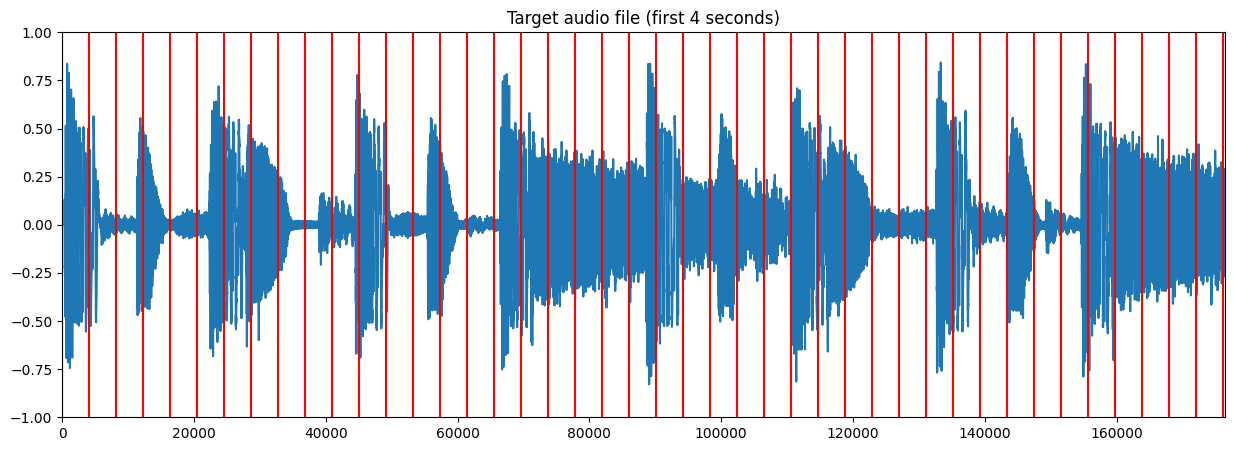

,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,None,None_f0,213524__garzul__120-bpm-distorded-drum-loop.wav,0,4096,0.014969,-610.609314,171.386307,19.981270,52.501530,12.665468,14.360890,10.304015,9.495301,-2.387431,10.962337,3.563853,-4.270400,4.410199
1,None,None_f1,213524__garzul__120-bpm-distorded-drum-loop.wav,4096,8192,0.006360,-760.779968,191.833786,15.245843,28.118511,4.100721,16.301201,17.526976,20.067717,10.209132,11.320103,2.673228,-0.605702,10.328066
2,None,None_f2,213524__garzul__120-bpm-distorded-drum-loop.wav,8192,12288,0.002600,-702.196350,35.689728,-17.177431,31.543301,-10.823902,7.278025,-8.849287,9.557547,16.805626,4.518951,7.588467,5.886111,3.015431
3,None,None_f3,213524__garzul__120-bpm-distorded-drum-loop.wav,12288,16384,0.003072,-632.422791,-14.642258,-57.702301,37.183216,-10.008492,14.882118,-6.809163,-4.061150,-5.629518,-10.711342,1.397487,1.584480,-1.667772
4,None,None_f4,213524__garzul__120-bpm-distorded-drum-loop.wav,16384,20480,0.000367,-788.471741,83.742508,-60.763344,2.984602,2.070751,5.210229,-24.195066,-3.615706,7.743684,3.316536,-9.738602,-14.365682,10.865704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,None,None_f81,213524__garzul__120-bpm-distorded-drum-loop.wav,331776,335872,0.014656,-600.834656,160.289993,14.284813,34.750778,7.389046,21.637875,9.320604,16.109564,11.054175,8.395454,2.966879,4.596795,2.262699
82,None,None_f82,213524__garzul__120-bpm-distorded-drum-loop.wav,335872,339968,0.007377,-564.974976,96.105690,-35.898285,-0.893806,-28.646303,-5.862800,1.169773,26.327982,21.833651,11.592172,3.552315,4.013518,-1.871525
83,None,None_f83,213524__garzul__120-bpm-distorded-drum-loop.wav,339968,344064,0.005988,-578.643799,107.279556,-42.246449,-4.723174,-29.391199,-11.231046,-13.430565,14.318197,21.213411,14.903108,0.107484,0.620052,-5.996817
84,None,None_f84,213524__garzul__120-bpm-distorded-drum-loop.wav,344064,348160,0.005655,-596.028259,122.856056,-36.042904,2.336622,-27.216124,-11.551359,-13.302413,12.089509,23.759695,18.790560,2.417027,-2.537498,-5.690632


,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,174080.000000,178176.000000,0.006218,-643.003845,112.991020,-24.843929,19.499214,-3.362056,10.335672,0.905217,11.547499,10.351719,4.320158,-4.426904,-4.004888,-0.090215
std,102277.046183,102277.046183,0.004499,94.961044,57.407070,25.355980,20.228325,19.722254,16.030067,8.976485,11.612940,9.044252,11.095074,10.915481,8.117366,7.404261
min,0.000000,4096.000000,0.000308,-920.770874,-14.642258,-76.731422,-19.720646,-41.484840,-14.107753,-24.195066,-15.307233,-8.862468,-15.657234,-45.453114,-24.915493,-12.621819
25%,87040.000000,91136.000000,0.002643,-700.569351,78.108444,-41.368768,1.673991,-21.451177,-4.040418,-3.785862,4.450365,4.943751,-2.364730,-11.290137,-8.440695,-5.521978
50%,174080.000000,178176.000000,0.005142,-617.491943,127.579773,-31.839147,15.760594,-3.233306,11.302720,0.576287,12.191216,10.288950,4.051546,-1.684171,-3.445392,-1.346438
75%,261120.000000,265216.000000,0.009551,-569.963303,155.286648,-10.527520,37.001501,12.579764,21.613176,5.596557,20.386653,16.643037,8.821375,3.172257,2.636582,3.485040
max,348160.000000,352256.000000,0.015879,-515.185242,195.265198,25.322586,57.142418,38.377842,40.672318,29.638008,34.052498,30.165390,49.542164,15.581572,10.368277,24.310286


In [8]:
TARGET_SOUND_PATH = '213524__garzul__120-bpm-distorded-drum-loop.wav'  # Filename of the target audio we'll reconstruct
DATAFRAME_TARGET_FILE_FILENAME = 'dataframe_target.csv'  # DataFrame file where to store the analysis results of the target audio

# Analyze the target audio file and store results in a new DataFrame
print('Analyzing target sound {0}'.format(TARGET_SOUND_PATH))
target_analysis = analyze_sound(TARGET_SOUND_PATH, frame_size=4096, sync_with_beats=False)  # Also split audio in chunks of 8192 samples (~185ms)
df_target = pd.DataFrame(target_analysis)
df_target.to_csv(DATAFRAME_TARGET_FILE_FILENAME)
print('Saved target dataframe with {0} entries! {1}'.format(len(df_target), DATAFRAME_TARGET_FILE_FILENAME))

# Plot target audio file waveform and show ticks at the start samples of the chunks
plt.figure(figsize=(15,5))
audio = estd.MonoLoader(filename=TARGET_SOUND_PATH)()
plt.plot(audio)
plt.vlines(df_target['start_sample'].values, -1, 1, color='red')
plt.axis([0, min(len(audio), 44100 * 4), -1, 1])
plt.title('Target audio file (first 4 seconds)')
plt.show()

display(df_target)  # Show data frame contents
df_target.describe()  # Show statistics of numerical fields in data frame

In [10]:
TARGET_SOUND_PATH = '213524__garzul__120-bpm-distorded-drum-loop.wav'  # Filename of the target audio we'll reconstruct
DATAFRAME_TARGET_FILE_FILENAME = 'dataframe_target.csv'  # DataFrame file where to store the analysis results of the target audio
def analyze_target(sound_path, dataframe_filename):
    # Analyze the target audio file and store results in a new DataFrame
    print('Analyzing target sound {0}'.format(sound_path))
    target_analysis = analyze_sound(sound_path, frame_size=4096, sync_with_beats=False)  # Also split audio in chunks of 8192 samples (~185ms)
    df_target = pd.DataFrame(target_analysis)
    df_target.to_csv(dataframe_filename)
    print('Saved target dataframe with {0} entries! {1}'.format(len(df_target), dataframe_filename))

    # Plot target audio file waveform and show ticks at the start samples of the chunks
    plt.figure(figsize=(15,5))
    audio = estd.MonoLoader(filename=sound_path)()
    plt.plot(audio)
    plt.vlines(df_target['start_sample'].values, -1, 1, color='red')
    plt.axis([0, min(len(audio), 44100 * 4), -1, 1])
    plt.title('Target audio file (first 4 seconds)')
    plt.show()

    display(df_target)  # Show data frame contents
    df_target.describe()  # Show statistics of numerical fields in data frame

Analyzing target sound 262350__stereo-surgeon__grinder-drum-loop.wav


[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Saved target dataframe with 318 entries! dataframe_target2.csv


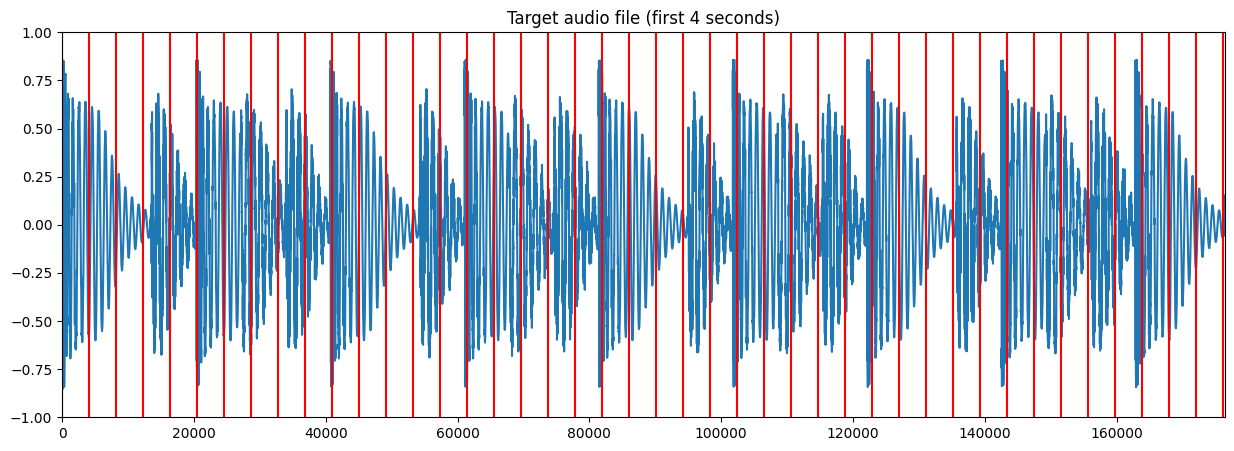

,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
0,None,None_f0,262350__stereo-surgeon__grinder-drum-loop.wav,0,4096,2.644737e-02,-751.980042,233.851303,49.840572,7.440356,18.348694,19.653893,12.211754,14.073494,5.899883,24.789280,12.542317,15.423445,6.050404
1,None,None_f1,262350__stereo-surgeon__grinder-drum-loop.wav,4096,8192,1.732880e-02,-1037.288940,248.976273,111.749451,33.135849,25.523493,33.289757,30.831314,23.435362,17.256922,15.375352,16.017456,15.021544,13.212188
2,None,None_f2,262350__stereo-surgeon__grinder-drum-loop.wav,8192,12288,4.040982e-03,-1147.957886,148.022919,106.635071,64.323997,38.200523,29.190695,27.490990,25.071791,21.710005,20.833382,22.952293,24.887526,24.158548
3,None,None_f3,262350__stereo-surgeon__grinder-drum-loop.wav,12288,16384,1.395295e-02,-601.594238,191.098541,-9.291850,8.720150,6.826436,12.837107,4.997464,17.419014,5.011023,4.292059,19.634378,9.435080,0.797040
4,None,None_f4,262350__stereo-surgeon__grinder-drum-loop.wav,16384,20480,8.828969e-03,-784.692871,260.375061,-38.253025,-20.359356,8.240650,13.772786,7.970800,16.013428,19.705269,19.296959,12.118035,8.802919,13.026264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,None,None_f313,262350__stereo-surgeon__grinder-drum-loop.wav,1282048,1286144,9.882231e-09,-1264.911621,0.000006,-0.000061,0.000023,-0.000078,0.000069,-0.000038,-0.000075,-0.000051,-0.000018,-0.000027,-0.000019,-0.000043
314,None,None_f314,262350__stereo-surgeon__grinder-drum-loop.wav,1286144,1290240,1.703303e-03,-744.768555,1.204088,-109.927887,-40.720760,-45.682911,-0.731565,-9.721689,-1.444695,3.063811,4.781573,24.339296,-5.664754,-22.150934
315,None,None_f315,262350__stereo-surgeon__grinder-drum-loop.wav,1290240,1294336,6.104910e-04,-869.140686,65.669685,-162.313416,-43.360123,-63.170147,-50.277958,-28.785816,-13.902730,-8.454066,-4.612569,-8.638612,0.273395,-0.438012
316,None,None_f316,262350__stereo-surgeon__grinder-drum-loop.wav,1294336,1298432,2.386146e-03,-637.703003,46.942184,-129.211044,-38.172218,-50.306030,-13.146418,-2.769713,-9.307549,-3.283922,7.803505,5.709835,2.513375,3.073954


In [11]:
analyze_target('262350__stereo-surgeon__grinder-drum-loop.wav', 'dataframe_target2.csv')

In [15]:
def analyze_sound(audio_path, frame_size=None, audio_id=None, sync_with_beats=False):
    """Analyze the audio file given in 'sound_path'.
    Use the parameter 'frame_size' to set the size of the chunks in which the audio will
    be split for analysis. If no frame_size is given, the whole audio will be analyzed as
    a single frame.
    Use the 'audio_id' parameter to pass a custom identifier for the audio that will be
    included in the analysis results. This can be useful to later identify to which file an analysis belongs.
    """
    analysis_output = []  # Here we'll store the analysis results for each chunk (frame) of the audio file

    # Load audio file
    loader = estd.MonoLoader(filename=audio_path)
    audio = loader()

    # Some processing of frame_size parameter to avoid later problems
    if frame_size is None:
        frame_size = len(audio)  # If no frame_size is given use no frames (analyze all audio at once)
    if frame_size % 2 != 0:
        frame_size = frame_size + 1 # Make frame size even

    # Calculate the start and end samples for each equally-spaced audio frame
    if sync_with_beats:
      beat_tracker_algo = estd.BeatTrackerDegara()
      beat_positions = beat_tracker_algo(audio)
      beat_positions = [int(round(position * 44100)) for position in beat_positions]
      frame_start_end_samples = zip(beat_positions[:-1], beat_positions[1:])
    else:
      frame_start_samples = range(0, len(audio), frame_size)
      frame_start_end_samples = zip(frame_start_samples[:-1], frame_start_samples[1:])

    # Iterate over audio frames and analyze each one
    for count, (fstart, fend) in enumerate(frame_start_end_samples):

        # Get corresponding audio chunk and initialize dictionary to sotre analysis results with some basic metadata
        frame = audio[fstart:fend]
        frame_output = {
            'freesound_id': audio_id,
            'id': '{0}_f{1}'.format(audio_id, count),
            'path': audio_path,
            'start_sample': fstart,
            'end_sample': fend,
        }

        # Extract loudness
        loudness_algo = estd.Loudness()
        loudness = loudness_algo(frame)
        frame_output['loudness'] = loudness / len(frame)  # Normnalize by length of frame

        # Extract MFCC coefficients, spectral centroid, chroma, and tonality
        w_algo = estd.Windowing(type = 'hann')
        spectrum_algo = estd.Spectrum()
        mfcc_algo = estd.MFCC()
        centroid_algo = estd.Centroid()
        spectral_peaks_algo = estd.SpectralPeaks()
        hpcp_algo = estd.HPCP()
        key_algo = estd.KeyExtractor()

        spec = spectrum_algo(w_algo(frame))
        _, mfcc_coeffs = mfcc_algo(spec)
        frame_output.update({'mfcc_{0}'.format(j): mfcc_coeffs[j] for j in range(0, len(mfcc_coeffs))})

        spectral_centroid = centroid_algo(spec)
        frame_output['spectral_centroid'] = spectral_centroid

        frequencies, magnitudes = spectral_peaks_algo(spec)
        chroma = hpcp_algo(frequencies, magnitudes)
        frame_output.update({'chroma_{0}'.format(j): chroma[j] for j in range(0, len(chroma))})

        # Extract tonality with Essentia KeyExtractor
        try:
            key, scale, key_strength = key_algo(frame)
        except Exception:
            key, scale, key_strength = None, None, 0.0
        frame_output['tonality_key'] = key
        frame_output['tonality_scale'] = scale
        frame_output['tonality_confidence'] = key_strength

        # Extract other features here and add to 'frame_output' dictionary
        # ...
        
        # Add frame analysis results to output
        analysis_output.append(frame_output)

    return analysis_output


In [16]:
DATAFRAME_FILENAME = 'dataframe.csv'  # DataFrame file of the sound source collection to analyze
DATAFRAME_SOURCE_FILENAME = 'dataframe_aug_source.csv'  # DataFrame file where to store the results of our analysis

# Load the DataFrame of the sound source collection created in previous notebook and analyze all sound files in it
df = pd.read_csv(open(DATAFRAME_FILENAME), index_col=0)
analyses = []
for i in range(0, len(df)):
    sound = df.iloc[i]  # Get DataFrame sound at position 'i'
    print('Analyzing sound with id {0} [{1}/{2}]'.format(sound['freesound_id'], i + 1, len(df)))
    try:
      analysis_output = analyze_sound(sound['path'], frame_size=8192, audio_id=sound['freesound_id'])  # Split audio in chunks of 8192 samples (~185ms)
      analyses += analysis_output
    except RuntimeError:
      continue

# Store analysis results in a new Pandas DataFrame and save it
df_source = pd.DataFrame(analyses)
df_source.to_csv(DATAFRAME_SOURCE_FILENAME)
print('Saved source DataFrame with {0} entries! {1}'.format(len(df_source), DATAFRAME_SOURCE_FILENAME))

display(df_source)  # Show DataFrane contents
df_source.describe()  # Show some statistics of numerical fields in the DataFrame

Analyzing sound with id 350674 [1/60]


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Analyzing sound with id 700476 [2/60]


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Analyzing sound with id 805257 [3/60]


...

[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Saved source DataFrame with 5108 entries! dataframe_aug_source.csv


[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (4097) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.


,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,...,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,tonality_key,tonality_scale,tonality_confidence
0,350674,350674_f0,files/350674_4162229-hq.ogg,0,8192,0.000003,-1196.923828,80.941429,46.385273,14.788477,...,0.874531,0.541735,0.725786,0.452571,0.952294,0.321703,0.259597,G,minor,0.468618
1,350674,350674_f1,files/350674_4162229-hq.ogg,8192,16384,0.000004,-1186.298340,91.349503,47.589100,10.576958,...,0.904570,0.750615,0.479943,0.691484,0.815801,0.150240,0.250485,Bb,minor,0.540097
2,350674,350674_f2,files/350674_4162229-hq.ogg,16384,24576,0.000004,-1184.613159,95.402481,53.823017,15.273584,...,0.951606,0.059640,0.138897,0.263964,1.000000,0.152962,0.142034,F#,minor,0.513960
3,350674,350674_f3,files/350674_4162229-hq.ogg,24576,32768,0.000005,-1182.153809,98.337326,54.797520,13.135248,...,0.292162,0.150782,0.142314,0.102121,1.000000,0.454824,0.103264,G,minor,0.687535
4,350674,350674_f4,files/350674_4162229-hq.ogg,32768,40960,0.000005,-1180.801025,100.293106,57.212284,16.585260,...,0.129407,0.199023,0.182434,0.247391,1.000000,0.051609,0.175609,Eb,minor,0.570544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5103,77096,77096_f215,files/77096_649468-hq.ogg,1761280,1769472,0.000048,-1160.867798,109.718033,46.556873,25.489313,...,0.183672,0.380625,1.000000,0.675743,0.096998,0.345777,0.430032,F#,minor,0.579478
5104,77096,77096_f216,files/77096_649468-hq.ogg,1769472,1777664,0.000032,-1180.838257,94.327133,51.225758,33.236252,...,0.781219,0.598164,1.000000,0.270158,0.309629,0.240847,0.374835,A,major,0.468483
5105,77096,77096_f217,files/77096_649468-hq.ogg,1777664,1785856,0.000023,-1195.997681,82.471733,53.414173,35.725571,...,0.796038,0.137445,1.000000,0.191845,0.245270,0.283740,0.393310,E,minor,0.368855
5106,77096,77096_f218,files/77096_649468-hq.ogg,1785856,1794048,0.000009,-1224.719727,54.852268,49.405231,41.850296,...,0.257827,0.380051,0.365441,0.540186,1.000000,0.393007,0.521651,E,minor,0.650463


,freesound_id,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,chroma_3,chroma_4,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,tonality_confidence
count,5108.000000,5.108000e+03,5.108000e+03,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,...,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000,5108.000000
mean,425059.327917,7.200171e+05,7.282091e+05,0.002147,-867.544250,144.838852,-14.270633,13.900637,2.827903,6.890910,...,0.331236,0.311876,0.302694,0.279853,0.302855,0.291306,0.339508,0.379852,0.367299,0.583384
std,237855.569711,5.577516e+05,5.577516e+05,0.003736,154.438004,55.536884,50.957443,22.634783,22.234705,18.033604,...,0.333676,0.319803,0.299766,0.286553,0.309934,0.309598,0.317410,0.340190,0.337397,0.163286
min,1930.000000,0.000000e+00,8.192000e+03,0.000000,-1264.911621,-33.554760,-178.381729,-102.807983,-62.538780,-75.829247,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,180156.000000,2.375680e+05,2.457600e+05,0.000237,-950.329071,118.711771,-43.006724,0.903271,-9.227072,-4.008397,...,0.019495,0.027570,0.048829,0.042844,0.035623,0.015301,0.057748,0.095802,0.078176,0.482702
50%,423450.000000,6.144000e+05,6.225920e+05,0.000764,-849.622162,147.999825,-7.758510,16.680377,5.653074,8.504648,...,0.227650,0.207687,0.211228,0.188570,0.209132,0.193654,0.253365,0.272521,0.262692,0.594938
75%,578743.000000,1.114112e+06,1.122304e+06,0.002292,-764.754730,184.261578,14.426863,27.446189,16.629182,18.585931,...,0.555395,0.512617,0.468413,0.420564,0.457307,0.454359,0.530612,0.609980,0.589779,0.700260
max,850571.000000,2.457600e+06,2.465792e+06,0.028754,-433.428772,294.240295,132.192871,81.795395,90.316055,57.085911,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.963522


Added:
- chroma 0 to 11: So that similar notes and chords are played if they are available
- spectral centroid: So that percussive sounds have a similar brightness
- tonality and scale: A bit redundant with chromas, but still good for identifying sounds that might not be playing the same note but are on the same key/scale
 

Analyzing target sound 262350__stereo-surgeon__grinder-drum-loop.wav


[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

Saved target dataframe with 318 entries! dataframe_target2_aug.csv


[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.
[   INFO   ] TriangularBands: input spectrum size (2049) does not correspond to the "inputSize" parameter (1025). Recomputing the filter bank.

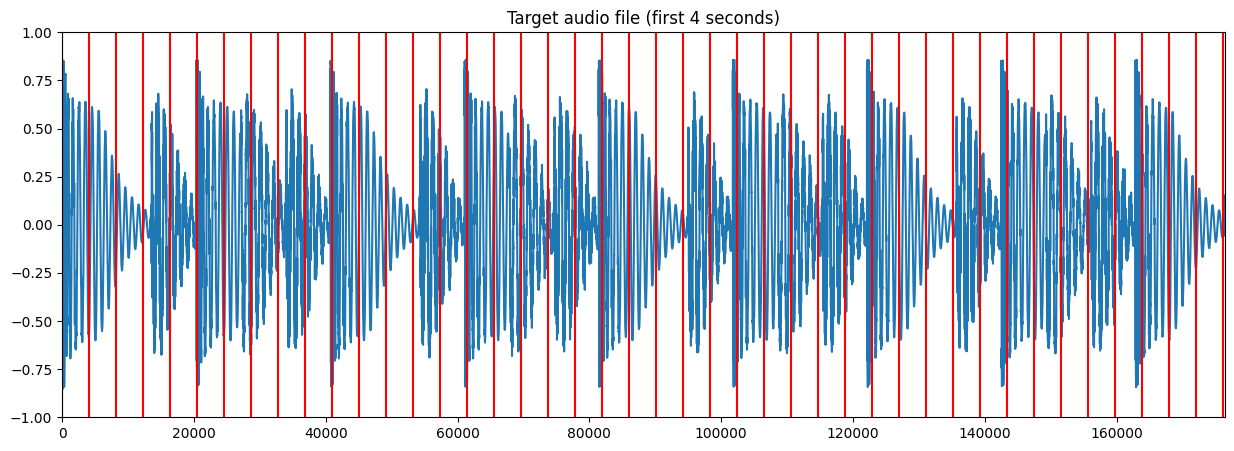

,freesound_id,id,path,start_sample,end_sample,loudness,mfcc_0,mfcc_1,mfcc_2,mfcc_3,...,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,tonality_key,tonality_scale,tonality_confidence
0,None,None_f0,262350__stereo-surgeon__grinder-drum-loop.wav,0,4096,2.644737e-02,-751.980042,233.851303,49.840572,7.440356,...,0.771069,0.032150,0.143029,0.397580,0.144532,1.000000,0.099940,Bb,minor,0.642338
1,None,None_f1,262350__stereo-surgeon__grinder-drum-loop.wav,4096,8192,1.732880e-02,-1037.288940,248.976273,111.749451,33.135849,...,0.816411,0.032778,0.524736,1.000000,0.115932,0.202607,0.264662,Bb,minor,0.865786
2,None,None_f2,262350__stereo-surgeon__grinder-drum-loop.wav,8192,12288,4.040982e-03,-1147.957886,148.022919,106.635071,64.323997,...,0.889908,0.043161,0.135146,1.000000,0.264168,0.068850,0.150618,G,minor,0.631747
3,None,None_f3,262350__stereo-surgeon__grinder-drum-loop.wav,12288,16384,1.395295e-02,-601.594238,191.098541,-9.291850,8.720150,...,0.068627,0.094242,0.300210,1.000000,0.435326,0.222821,0.228091,Eb,minor,0.601135
4,None,None_f4,262350__stereo-surgeon__grinder-drum-loop.wav,16384,20480,8.828969e-03,-784.692871,260.375061,-38.253025,-20.359356,...,0.021450,0.061179,0.027435,1.000000,0.304395,0.023316,0.047655,A,major,0.433135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,None,None_f313,262350__stereo-surgeon__grinder-drum-loop.wav,1282048,1286144,9.882231e-09,-1264.911621,0.000006,-0.000061,0.000023,...,0.284108,0.441778,0.566027,0.762106,0.631067,0.317788,0.279120,A,minor,0.000000
314,None,None_f314,262350__stereo-surgeon__grinder-drum-loop.wav,1286144,1290240,1.703303e-03,-744.768555,1.204088,-109.927887,-40.720760,...,0.043048,1.000000,0.064930,0.222027,0.221589,0.751104,0.115521,F,major,0.559546
315,None,None_f315,262350__stereo-surgeon__grinder-drum-loop.wav,1290240,1294336,6.104910e-04,-869.140686,65.669685,-162.313416,-43.360123,...,0.492373,0.118033,0.075611,0.665343,1.000000,0.131713,0.995114,C,minor,0.491958
316,None,None_f316,262350__stereo-surgeon__grinder-drum-loop.wav,1294336,1298432,2.386146e-03,-637.703003,46.942184,-129.211044,-38.172218,...,0.155859,0.823404,0.228693,0.498464,0.711368,0.262919,1.000000,C#,minor,0.591247


In [18]:
analyze_target('262350__stereo-surgeon__grinder-drum-loop.wav', 'dataframe_target2_aug.csv')